In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata = ad.read_h5ad("./data/adata_cleaned.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 2092 × 14046
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id_snp', 'hashedDrops_Best', 'hashedDrops_Second', 'hashedDrops_LogFC', 'hashedDrops_LogFC2', 'hashedDrops_Doublet', 'hashedDrops_Confident', 'hashedDrops_classification', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Donor_ID_HTOdemux_localSNP', 'Timepoint', 'tetramer_batch', 'dosage', 'HTO_SNP_agreed_donor', 'S.Score', 'G2M.Score', 'Phase', 'latent_donor', 'latent_HTO', 'sort_person', 'GEM_date', 'library_prep_date', 'GEM_storage_day', 'GEM_prep_person', 'PCR_cycle', 'Donor_ID_conservative', 'RNA_snn_res.0.5', 'seurat_clusters', 'donor_1pct', 'donor_hybrid', 'sample', 'condition', 'TCR_alpha1', 'TCR_alpha2', 'TCR_beta', 'V_alpha1', 'J_alpha1', 'C_alpha1', 'V_beta', 'J_beta', 'C_beta', 'nCount_SCT', 'nFeature_SCT', 'clusters_UMAP', 'RNA_snn_res.0.8', 'Naive_pos', 'Naive_neg'

## Proportion of expanded cells per time point (treatment dose)

/tmp/ipykernel_2333849/877966936.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expanded_counts = df_expanded.groupby('time').size().reset_index(name='expanded_cells')
/tmp/ipykernel_2333849/877966936.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = df.groupby('time').size().reset_index(name='total_cells')


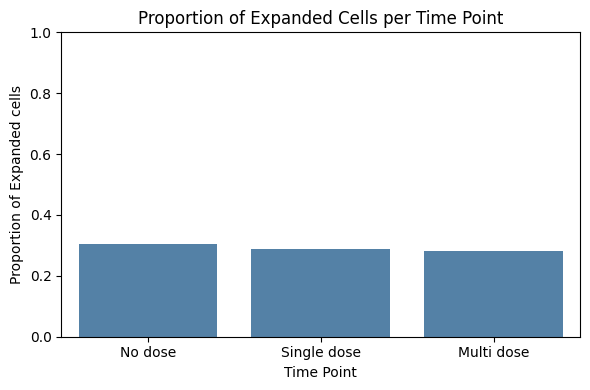

In [4]:
df = adata.obs[['expand_response', 'time']].copy()

df_expanded = df[df['expand_response'].str.startswith('Expanded_')].copy()

expanded_counts = df_expanded.groupby('time').size().reset_index(name='expanded_cells')

# Count total cells per time point
total_counts = df.groupby('time').size().reset_index(name='total_cells')

# Merge and compute proportion
merged = expanded_counts.merge(total_counts, on='time')
merged['proportion'] = merged['expanded_cells'] / merged['total_cells']

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=merged, x='time', y='proportion', color='steelblue')
plt.ylabel('Proportion of Expanded cells')
plt.xlabel('Time Point')
plt.title('Proportion of Expanded Cells per Time Point')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Mean percentage of cells per cluster and treatment dose

In [ ]:
cluster_patient_time_counts = adata.obs.groupby(['seurat_clusters', 'patient_name', 'time']).size().reset_index(name='count')

total_cells_per_patient_time = cluster_patient_time_counts.groupby(['patient_name', 'time'])['count'].transform('sum')

cluster_patient_time_counts['percentage'] = cluster_patient_time_counts['count'] / total_cells_per_patient_time * 100

# Pivot the table to have 'seurat_clusters' as columns and 'patient_name' and 'time' as index
percentage_df = cluster_patient_time_counts.pivot_table(index=['patient_name', 'time'], columns='seurat_clusters', values='percentage', fill_value=0)

percentage_df


/tmp/ipykernel_1865595/3657131191.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_patient_time_counts = adata.obs.groupby(['seurat_clusters', 'patient_name', 'time']).size().reset_index(name='count')
/tmp/ipykernel_1865595/3657131191.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells_per_patient_time = cluster_patient_time_counts.groupby(['patient_name', 'time'])['count'].transform('sum')
/tmp/ipykernel_1865595/3657131191.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to sil

seurat_clusters                   0          1          2          3  \
patient_name time                                                      
P1           No dose      28.205128   7.692308  10.256410   7.692308   
             Single dose  31.578947   6.315789  22.631579   6.315789   
             Multi dose   15.217391  21.739130  19.565217   2.173913   
P2           No dose      41.304348   2.173913   2.173913  29.347826   
             Single dose  38.709677   6.451613  12.903226   3.225806   
             Multi dose   21.189591   5.947955  14.126394  18.959108   
P4           No dose      16.393443  27.868852   5.737705  12.295082   
             Single dose  14.356436  34.653465   5.445545   3.960396   
             Multi dose   18.918919  22.972973   8.783784   6.081081   
P6           No dose      20.000000  16.363636  16.363636   5.454545   
             Single dose  18.316832   7.425743   9.405941   3.465347   
             Multi dose   22.881356   5.084746  10.169492   6.779661   
P7           No dose      41.791045  20.895522  20.895522   4.477612   
             Single dose  48.780488  14.634146  19.512195   4.878049   
             Multi dose   28.947368  21.929825  14.035088   5.263158   
P8           No dose      37.878788   3.030303  10.606061   4.545455   
             Single dose  19.580420   9.090909  16.083916  11.188811   
             Multi dose   35.374150   0.680272  29.251701   7.482993   

seurat_clusters                   4          5          6          7  \
patient_name time                                                      
P1           No dose      20.512821  15.384615   2.564103   5.128205   
             Single dose   9.473684   6.315789   5.263158   8.421053   
             Multi dose   10.869565   2.173913  10.869565  17.391304   
P2           No dose       7.608696   6.521739   0.000000   3.260870   
             Single dose  12.903226  16.129032   0.000000   3.225806   
             Multi dose   13.754647   7.806691   4.832714   5.204461   
P4           No dose      12.295082  16.393443   0.819672   2.459016   
             Single dose   4.950495   2.475248  13.861386   3.960396   
             Multi dose    4.054054  12.837838  16.891892   4.729730   
P6           No dose      10.909091  10.909091  10.909091   1.818182   
             Single dose   1.980198   6.435644  33.168317  14.851485   
             Multi dose    5.932203   8.474576   8.474576  23.728814   
P7           No dose       0.000000   1.492537   2.985075   5.970149   
             Single dose   2.439024   0.000000   4.878049   0.000000   
             Multi dose    2.631579   6.140351   5.263158   8.771930   
P8           No dose       6.060606   1.515152  18.181818  10.606061   
             Single dose  13.286713   9.790210   8.391608   9.090909   
             Multi dose    5.442177   4.761905   4.761905   8.843537   

seurat_clusters                  8          9  
patient_name time                              
P1           No dose      2.564103   0.000000  
             Single dose  3.684211   0.000000  
             Multi dose   0.000000   0.000000  
P2           No dose      7.608696   0.000000  
             Single dose  3.225806   3.225806  
             Multi dose   7.063197   1.115242  
P4           No dose      5.737705   0.000000  
             Single dose  1.485149  14.851485  
             Multi dose   2.702703   2.027027  
P6           No dose      7.272727   0.000000  
             Single dose  3.960396   0.990099  
             Multi dose   6.779661   1.694915  
P7           No dose      1.492537   0.000000  
             Single dose  4.878049   0.000000  
             Multi dose   5.263158   1.754386  
P8           No dose      7.575758   0.000000  
             Single dose  2.797203   0.699301  
             Multi dose   3.401361   0.000000

In [18]:
percentage_df.to_excel("./results/percentage_per_cluster.xlsx")

/tmp/ipykernel_1865595/2215439884.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_combined = combined_df.groupby('time').mean().reset_index()


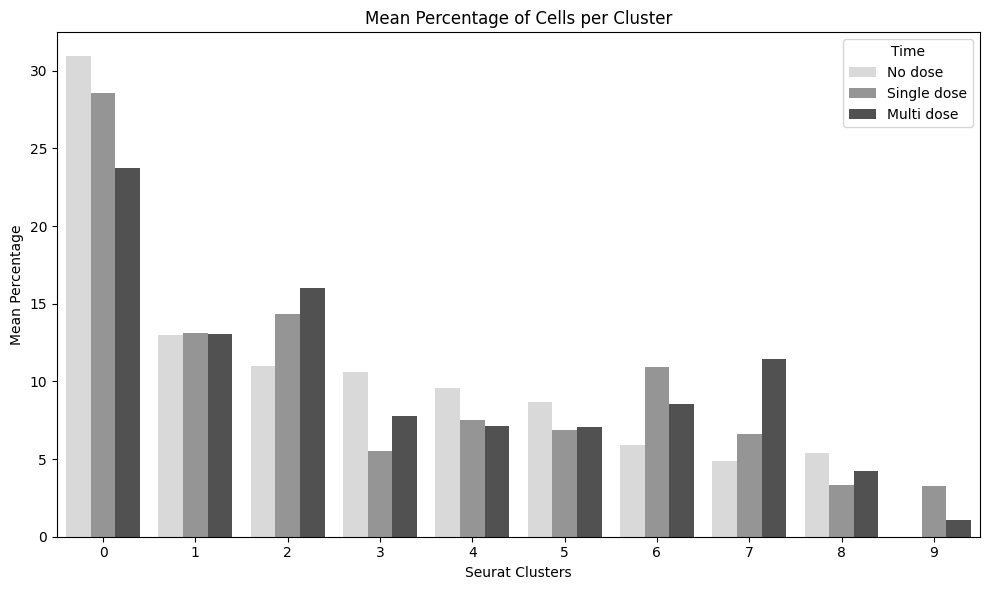

In [6]:
combined_df = percentage_df.copy()

# Calculate the mean percentage for each cluster and time
mean_combined = combined_df.groupby('time').mean().reset_index()

# Melt the DataFrame to convert seurat_clusters from columns to rows
melted_combined = mean_combined.melt(id_vars='time', var_name='seurat_clusters', value_name='percentage')

# Plot the bar graph using Seaborn with a greyscale color palette
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_combined, x='seurat_clusters', y='percentage', hue='time', palette='Greys')
plt.title('Mean Percentage of Cells per Cluster')
plt.ylabel('Mean Percentage')
plt.xlabel('Seurat Clusters')
plt.legend(title='Time')
plt.tight_layout()
plt.show()
